# Task 4: Simple Fashion Visual Search

Compare fixed image features using cosine similarity. The authorized validation tuning and execution protocol is recorded in [TASK4_RESULTS.md](../TASK4_RESULTS.md). No pretrained model or neural training is used.

## 1. Setup

In [1]:
from pathlib import Path
import json
import sys
import time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch  # Serialization only; retrieval uses NumPy on CPU.

from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG
from scripts.preprocessing import SEED, task_frame
from scripts.retrieval import embed_images, retrieval_metrics

FEATURES = {
    'pixel': {'image_size': [12, 16]},
    'hog_hsv': dict(DEFAULT_FEATURE_CONFIG),
}
for shape_weight in (0.25, 0.50, 0.75):
    FEATURES[f'hog_hsv_shape_{shape_weight:.2f}'] = {**DEFAULT_FEATURE_CONFIG, 'shape_weight': shape_weight}

def feature_type(method):
    return 'pixel' if method == 'pixel' else 'hog_hsv'

(ROOT / '.cache/task4-run').mkdir(parents=True, exist_ok=True)


## 2. Gallery, validation queries and test queries

Training rows form the evaluation gallery. **Validation** queries select the
feature method; test queries are evaluated only after that choice is frozen.
Primary relevance means matching article type, not human-rated visual similarity.
These are the existing group-isolated partitions, not a new untouched holdout.

In [2]:
train_df = task_frame('articleType', 'train')
validation_df = task_frame('articleType', 'validation')
test_df = task_frame('articleType', 'test')
for query_frame in (validation_df, test_df):
    assert set(train_df.group_key).isdisjoint(query_frame.group_key)
assert set(validation_df.group_key).isdisjoint(test_df.group_key)
pd.Series({'gallery': len(train_df), 'validation_queries': len(validation_df),
           'test_queries': len(test_df)})

gallery               27051
validation_queries     5842
test_queries           5718
dtype: int64

## 3. Compare fixed representations and block weightings on validation

Pixel vectors capture colour and coarse layout. HOG captures local edge patterns;
HSV histograms summarize colour. Both use bilinear resizing and unit-length
vectors. Their shared definitions are in [search_features.py](../app/server/utils/search_features.py).

Select the highest validation precision@5. Exact ties use mean reciprocal rank,
then fewer feature dimensions, then the method name for deterministic ordering.
Precision@k is the matching fraction of k results; hit rate@k means at least one
match; recall@k divides matching results by **all relevant gallery items**.
MRR measures the rank of the first matching item. Query averages favor common
classes; class support and the qualitative examples matter too.

Three additional settings normalize shape and colour blocks separately and use shape weights 0.25, 0.50 and 0.75. The complete grid was fixed before evaluation.

In [3]:
gallery_features = {}
comparison_rows = []
for method, config in FEATURES.items():
    started = time.perf_counter()
    gallery = embed_images(train_df, feature_type(method), config)
    queries = embed_images(validation_df, feature_type(method), config)
    metrics = retrieval_metrics(queries, gallery,
                                validation_df.articleType, train_df.articleType)
    gallery_features[method] = gallery
    comparison_rows.append({
        'method': method, **metrics, 'dimensions': gallery.shape[1],
        'gallery_mib': gallery.nbytes / 1024**2,
        'feature_and_evaluation_seconds': time.perf_counter() - started,
    })
comparison = pd.DataFrame(comparison_rows).set_index('method')
display(comparison)
ranked = comparison.reset_index().sort_values(
    ['precision@5', 'mean_reciprocal_rank', 'dimensions', 'method'],
    ascending=[False, False, True, True],
)
SELECTED_METHOD = ranked.iloc[0]['method']
print('Frozen method before test evaluation:', SELECTED_METHOD)
comparison.to_csv(ROOT / '.cache/task4-run/validation_comparison.csv')
(ROOT / '.cache/task4-run/decision.json').write_text(json.dumps({'selected': SELECTED_METHOD, 'config': FEATURES[SELECTED_METHOD], 'frozen_before_test': True}, indent=2))

,precision@1,hit_rate@1,recall@1,precision@5,hit_rate@5,recall@5,precision@10,hit_rate@10,recall@10,mean_reciprocal_rank,dimensions,gallery_mib,feature_and_evaluation_seconds
method,,,,,,,,,,,,,
pixel,0.728689,0.728689,0.003140,0.669189,0.893872,0.010419,0.639079,0.930674,0.017237,0.802179,576,59.438232,25.913204
hog_hsv,0.769428,0.769428,0.003380,0.722629,0.926737,0.011906,0.695344,0.951387,0.020344,0.838064,1284,132.497726,41.587664
hog_hsv_shape_0.25,0.772852,0.772852,0.003371,0.726327,0.924170,0.012115,0.698117,0.952414,0.020560,0.839438,1284,132.497726,45.623229
hog_hsv_shape_0.50,0.790312,0.790312,0.003592,0.745840,0.932729,0.012849,0.720181,0.961486,0.021614,0.853390,1284,132.497726,46.842655
hog_hsv_shape_0.75,0.798699,0.798699,0.003717,0.751387,0.934269,0.012968,0.724803,0.960801,0.021802,0.858717,1284,132.497726,46.428694


Frozen method before test evaluation: hog_hsv_shape_0.75


298

## 4. Evaluate the selected method on test queries

The fixed method is evaluated once here. Do not change feature settings in response
to this table. This is a follow-up on the existing partitions; previous test
exposure must be disclosed in the final report.

In [4]:
gallery_embeddings = gallery_features[SELECTED_METHOD]
query_embeddings = embed_images(test_df, feature_type(SELECTED_METHOD), FEATURES[SELECTED_METHOD])
test_metrics = retrieval_metrics(query_embeddings, gallery_embeddings,
                                 test_df.articleType, train_df.articleType)
pd.Series(test_metrics, name='selected_method_test')
(ROOT / '.cache/task4-run/test_metrics.json').write_text(json.dumps(test_metrics, indent=2))
display(pd.Series(test_metrics, name='selected_method_test'))


precision@1             0.797831
hit_rate@1              0.797831
recall@1                0.002747
precision@5             0.748304
hit_rate@5              0.933019
recall@5                0.010655
precision@10            0.719150
hit_rate@10             0.959077
recall@10               0.018326
mean_reciprocal_rank    0.858070
Name: selected_method_test, dtype: float64

## 5. Attribute agreement and examples

In [5]:
top_five = []
for start in range(0, len(query_embeddings), 64):
    scores = query_embeddings[start:start+64] @ gallery_embeddings.T
    top_five.extend(np.argsort(-scores, axis=1, kind='stable')[:, :5])
top_five = np.asarray(top_five)
attribute_agreement = {}
for attribute in ('articleType', 'baseColour', 'gender', 'usage', 'subCategory'):
    query_values = test_df[attribute].to_numpy()[:, None]
    retrieved_values = train_df[attribute].to_numpy()[top_five]
    valid = (query_values != '') & (retrieved_values != '')
    attribute_agreement[attribute] = {
        'agreement': float((query_values == retrieved_values)[valid].mean()) if valid.any() else np.nan,
        'valid_pairs': int(valid.sum()),
    }
display(pd.DataFrame(attribute_agreement).T)
pd.DataFrame(attribute_agreement).T.to_csv(ROOT / '.cache/task4-run/attribute_agreement.csv')
per_query = pd.DataFrame({'id': test_df.id.to_numpy(), 'articleType': test_df.articleType.to_numpy(), 'precision@5': (train_df.articleType.to_numpy()[top_five] == test_df.articleType.to_numpy()[:, None]).mean(1)})
per_class = per_query.groupby('articleType').agg(queries=('id','size'), precision_at_5=('precision@5','mean'))
display(per_class.sort_values('precision_at_5').head(15))
per_class.to_csv(ROOT / '.cache/task4-run/per_class.csv')
np.save(ROOT / '.cache/task4-run/top_five.npy', top_five)

,agreement,valid_pairs
articleType,0.748304,28590.0
baseColour,0.256313,28590.0
gender,0.839210,28590.0
usage,0.847219,28590.0
subCategory,0.921616,28590.0


,queries,precision_at_5
articleType,,
Camisoles,1,0.000000
Bracelet,1,0.000000
Footballs,1,0.000000
Clothing Set,1,0.000000
Jumpsuit,1,0.000000
Tablet Sleeve,1,0.000000
Tights,1,0.000000
Rucksacks,1,0.000000
Swimwear,2,0.000000


Attribute agreement is a secondary diagnostic; literal `NA` counts as a usage
label, while genuinely blank pairs are excluded and their support is reported.
The fixed panel below includes common and rare article types plus catalogue
examples. It is descriptive, not a curated demonstration of only good matches.

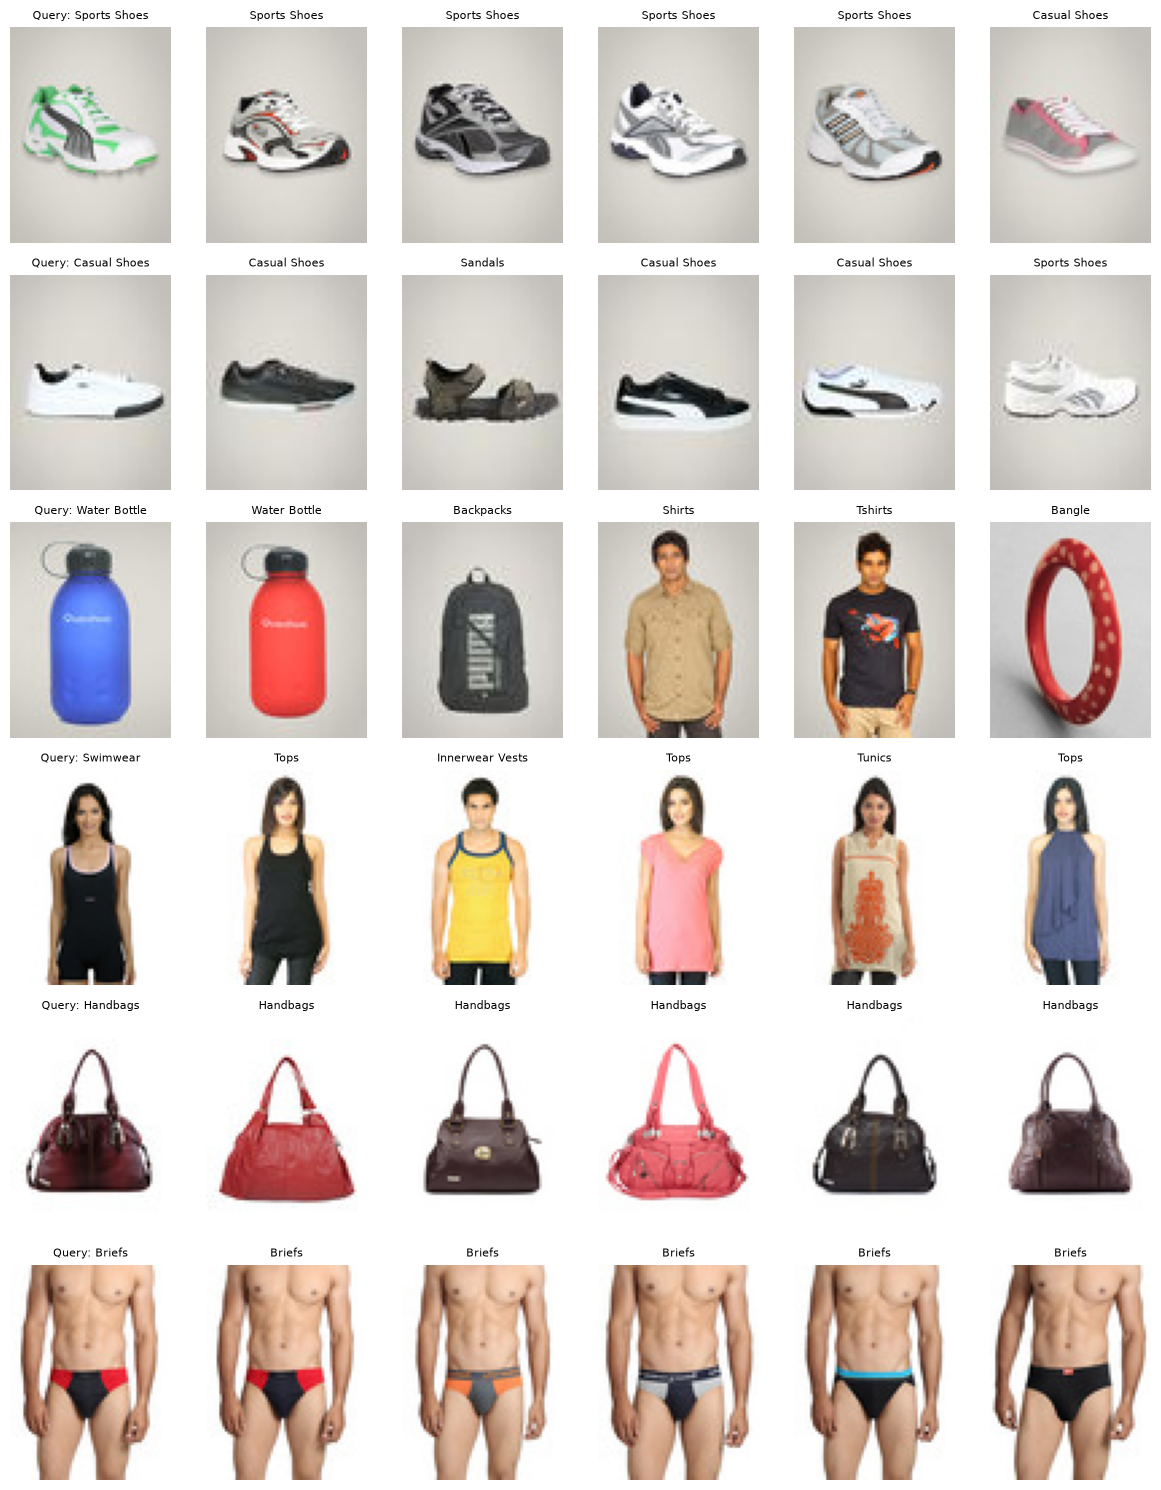

In [6]:
support = train_df.articleType.value_counts()
common = test_df.loc[test_df.articleType.isin(support.head(5).index)].head(2)
rare = test_df.loc[test_df.articleType.map(support).le(49)].head(2)
panel = pd.concat([common, rare, test_df.sample(6, random_state=SEED)])
query_indices = panel.drop_duplicates('id').head(6).index
positions = test_df.index.get_indexer(query_indices)
fig, axes = plt.subplots(len(positions), 6, figsize=(12, 2.5 * len(positions)), squeeze=False)
for row, position in enumerate(positions):
    items = [test_df.iloc[position]]
    items.extend(train_df.iloc[index] for index in top_five[position])
    for column, item in enumerate(items):
        with Image.open(item.image_path) as image:
            axes[row, column].imshow(image.convert('RGB'))
        axes[row, column].set_title(('Query: ' if column == 0 else '') + item.articleType, fontsize=8)
        axes[row, column].axis('off')
plt.tight_layout()
fig.savefig(ROOT / '.cache/task4-run/retrieval_examples.png', dpi=130, bbox_inches='tight')
figures = ROOT / 'figures'
figures.mkdir(exist_ok=True)
fig.savefig(figures / 'retrieval_examples.png', dpi=220, bbox_inches='tight')


## 6. Verify a deployment gallery after evaluation

Rebuild the deployment artifacts in `.cache/notebook-refresh/task4/` and compare the selected configuration and retrieval metrics against the active checkpoint. Active application artifacts remain unchanged.

In [7]:
deployment_gallery = pd.concat([train_df, validation_df, test_df], ignore_index=True)
deployment_gallery = deployment_gallery.drop_duplicates('id')
deployment_embeddings = embed_images(deployment_gallery, feature_type(SELECTED_METHOD), FEATURES[SELECTED_METHOD])
checkpoint = {
    'model_type': 'fixed_feature_cosine', 'feature_type': feature_type(SELECTED_METHOD), 'selected_method': SELECTED_METHOD,
    'feature_config': FEATURES[SELECTED_METHOD],
    'embedding_dim': deployment_embeddings.shape[1],
    'selection_metric': 'validation_precision@5',
    'validation_metrics': comparison.loc[SELECTED_METHOD].to_dict(),
    'retrieval_metrics': test_metrics, 'seed': SEED,
    'experiment': 'fixed_feature_search_v1',
}
model_dir = ROOT / '.cache/notebook-refresh/task4'
model_dir.mkdir(parents=True, exist_ok=True)
np.save(model_dir / 'visual_search_embeddings.npy', deployment_embeddings)
deployment_gallery[['id', 'image_path', 'articleType', 'baseColour', 'gender', 'usage', 'subCategory']].to_csv(
    model_dir / 'visual_search_metadata.csv', index=False,
)
torch.save(checkpoint, model_dir / 'visual_search_model.pt')
comparison.to_csv(model_dir / 'visual_search_history.csv')
print('Deployment index MiB:', deployment_embeddings.nbytes / 1024**2)
active = torch.load(ROOT / 'models/visual_search_model.pt', map_location='cpu', weights_only=False)
assert active['feature_config'] == checkpoint['feature_config']
for key, value in test_metrics.items():
    np.testing.assert_allclose(value, active['retrieval_metrics'][key], atol=1e-8)
print('Active retrieval configuration and metrics reproduced; application artifacts unchanged.')


Deployment index MiB: 189.1194305419922
Active retrieval configuration and metrics reproduced; application artifacts unchanged.


## 7. Interpretation and web verification

Gallery: 27,051 training images; validation: 5,842 queries; test: 5,718 queries. All notebook code cells executed successfully.

| Method | Validation precision@5 | Validation MRR |
|---|---:|---:|
| pixel | 66.92% | 0.8022 |
| hog_hsv | 72.26% | 0.8381 |
| hog_hsv_shape_0.25 | 72.63% | 0.8394 |
| hog_hsv_shape_0.50 | 74.58% | 0.8534 |
| hog_hsv_shape_0.75 | 75.14% | 0.8587 |

Selected **75% shape / 25% colour**, improving validation precision@5 by 2.88 percentage points over raw HOG+HSV. The test was used only after this choice.

| Test metric | Result |
|---|---:|
| precision@1 | 0.7978 |
| hit_rate@1 | 0.7978 |
| recall@1 | 0.0027 |
| precision@5 | 0.7483 |
| hit_rate@5 | 0.9330 |
| recall@5 | 0.0107 |
| precision@10 | 0.7192 |
| hit_rate@10 | 0.9591 |
| recall@10 | 0.0183 |
| mean_reciprocal_rank | 0.8581 |

Class-macro precision@5 is **51.45%**, much lower than the query-weighted **74.83%**: common classes drive the aggregate. Recall@5 is only 1.07%, since its denominator includes every same-category training image; hit rate@5 answers the different question of whether any relevant image is found.

Attribute agreement among five results: article type 74.83%, subcategory 92.16%, gender 83.92%, usage 84.72%, colour 25.63%. These are retrieval agreements, not classifier accuracies. Colour remains a weakness despite including HSV; the selected objective favors article category and shape.

The fixed example panel shows all five handbag and brief results matching their categories. Footwear results mix casual/sports styles and sandals. The water bottle retrieves another bottle first but unrelated products afterwards; swimwear retrieves tops/vests rather than swimwear. Among categories with at least 30 test queries, Tunics (10.91% P@5), Kurtis (19.49%) and Sweaters (24.55%) perform poorly. No claim of superiority to the old neural encoder is made because it was not reevaluated under this protocol.

Deployment index: **38,611 catalogue rows**, 1284 dimensions, 189.12 MiB. Ten warm CPU searches on one fixed validation image had median 73.1 ms and maximum 82.0 ms; this is a local smoke measurement, not a load benchmark. CLI rankings and scores match direct search.

### 7.1 Historical web UI classification

The following browser results were recorded before the latest article checkpoint replacement; browser tests were not repeated during this notebook refresh. The later check is documented in [SIMPLE_TRAINING_TRIALS.md](../SIMPLE_TRAINING_TRIALS.md), including the current 65% original and 82% darkened T-shirt errors.

Eight Chromium uploads were exercised through the Next.js proxy and FastAPI: six deterministic category examples, plus brightness 0.8 and 1.2 variants of the T-shirt, created only in memory. All four predictions matched direct CPU inference. All five gallery images loaded on each upload; no browser page errors occurred. History survived reload, the 390-pixel mobile layout had no horizontal overflow, and non-image uploads were rejected.

| Image | True article | Predicted article | Correct attributes / 4 |
|---|---|---|---:|
| 1562 (original) | Tshirts | Sweatshirts | 3 |
| 1917 (original) | Casual Shoes | Formal Shoes | 2 |
| 4706 (original) | Watches | Watches | 2 |
| 1597 (original) | Handbags | Handbags | 2 |
| 2710 (original) | Dresses | Dresses | 3 |
| 4977 (original) | Jeans | Jeans | 4 |
| 1562 (dark) | Tshirts | Sweatshirts | 3 |
| 1562 (bright) | Tshirts | Tshirts | 4 |

These examples are not a random accuracy sample. The first T-shirt was classified as Sweatshirts (69% confidence, not flagged), and darkening increased that wrong confidence to 90%. Brightening corrected this example, but that does not establish a generally beneficial preprocessing rule. The casual-shoe image was called Formal Shoes and correctly flagged for review; its incorrect seasonal prediction was not flagged. Audience errors also occurred for the watch, handbag and dress. The historical results are summarized in [TASK4_RESULTS.md](../TASK4_RESULTS.md); standalone experiment exports were subsequently removed. The unchanged classifier test metrics remain the appropriate aggregate reference.

All eight uploaded catalogue images retrieved themselves at rank one, including the brightness variants. The deployment gallery includes those validation images; this demonstrates self-match functionality, not unseen-query retrieval quality. The 74.83% test precision@5 above uses the disjoint training-only gallery and is the relevant held-out score. No retrieval label was substituted into the classifier outputs.

### 7.2 Historical implementation changes and verification

- Executed `notebooks/task4_visual_search_analysis.ipynb`, retained outputs, and added numerical/qualitative interpretation.
- Added the small shape/colour weighting option in `app/server/utils/search_features.py`; selected settings are saved with the search checkpoint.
- Replaced the four visual-search artifacts with the fixed-feature index and validation comparison.
- Catalogue cards now preserve full image framing and show a cosine similarity score rather than a misleading percentage. TypeScript and targeted ESLint checks pass.
- Retrieval metric/tie behavior and finite features for blank images checked. Saved index dimensions, row alignment, ID uniqueness, unit norms, CLI and browser behavior verified.
- Original dataset and frozen manifest hashes unchanged. All four classifier checkpoints and Tasks 0-3 notebook bytes unchanged. No pretrained weights, commit, push or deployment.
- Reproducible browser script: `experiments/verify_task4_web.py` (requires Playwright and Chromium). Execution log and full browser responses: `.cache/task4-run/`. Previous search artifacts: `.cache/task4-run/before/models/`.
- Shareable evidence: `experiments/task4_validation_comparison.csv`, `task4_per_class.csv`, `task4_attribute_agreement.csv`, `task4_retrieval_examples.png`, `task4_web_result_0.png`, and `task4_web_mobile.png`.

The local app is available at http://127.0.0.1:3000 while the development servers remain running.


See [TASK4_RESULTS.md](../TASK4_RESULTS.md) for the full change record and paths relative to the repository root.

## 8. Report refresh verification

The fresh run reproduced the same 75% shape / 25% colour configuration, validation precision@5 **75.14%**, internal-test precision@5 **74.83%**, hit rate@5 **93.30%**, and MRR **0.8581**. The rebuilt deployment gallery is written to `.cache/notebook-refresh/task4/`, while active artifacts remain unchanged. Updated retrieval examples are exported to `figures/retrieval_examples.png`. The timings and browser results in Section 7 describe the earlier integration run, not new browser testing.